In [1]:
from utils import *
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from glob import glob

50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..
50 trajectories used..


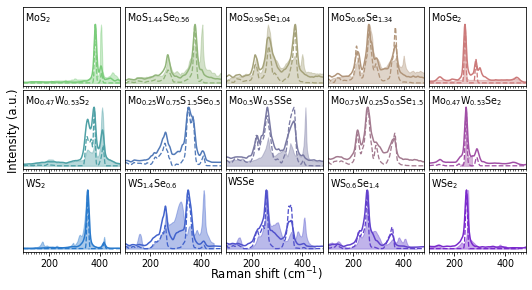

In [2]:
temp = 300 
timesteps = 10000
nsteps = 10000
nsamples = 50


freq_lim = (50,700)
std_full = 3
std_first = 3
interval = 1
freq_scale_full = 1.045
freq_scale_first = 1.035

fontsize = 9.5

plt.rcParams['font.size'] = fontsize
fig, axs = plt.subplots(3, 5, figsize=(9, 4.5))  # transposed layout

## 2D Composition array according to shown in plot
comps = np.array([[[0,1],[0.53,1],[1,1]],
                  [[0,0.67],[0.25,0.75],[1,0.7]],
                  [[0,0.52],[0.5,0.5],[1,0.5]],
                  [[0,0.28],[0.75,0.25],[1,0.3]],
                  [[0,0],[0.53,0],[1,0]]])

folder_expt = 'expt_alloys' ## Folder containing experimental results
folder_first = 'first_order_raman/' ## Folder containing First order results
trajfolder = 'monolayer_md_data/' ## Folder containing all trajectories

for i in range(5):  # original rows
    for j in range(3):  # original columns
        #ax = axs[2-j][4-i]  # transposed index
        ax = axs[j][4-i]
        xspace = np.linspace(0, 500, 5000)
        x, y = comps[i][j]
        color = get_alloy_color(x, y)

        if j == 0:
            composition = 'MoSSe'
            xmin, xmax = 100, 480
        elif j == 2:
            composition = 'WSSe'
            xmin, xmax = 100, 480
        elif i == 0:
            composition = 'MoWSe2'
            xmin, xmax = 100, 480
        elif i == 4:
            composition = 'MoWS2'
            xmin, xmax = 100, 480
        else:
            composition = 'MoWSSe'
            xmin, xmax = 100, 480

        if not (x == 0.25 or x == 0.75):
            data = pd.read_csv(f'{folder_expt}/{composition}/x{x:.3f}y{y:.3f}.csv', header=None)
            xdata_expt = data[0].values
            ydata_expt = data[1].values
            ax.fill_between(xdata_expt, ydata_expt, min(ydata_expt), alpha=0.4, color=color)

        # Full Raman spectra
        freqs, avg_intens = calculate_average_spectra(
            trajfolder, x, y, temp, timesteps, nsteps, nsamples,
            interval, xspace, freq_lim, std_full
        )
        freqs *= freq_scale_full
        if not (x == 0.25 or x == 0.75):
            intens_scale = (max(data[1]) - min(data[1])) / max(avg_intens)
            avg_intens = avg_intens * intens_scale + min(ydata_expt)

        ax.plot(freqs, avg_intens, color=color)

        # First-order Raman
        nconfig = 1 if (y == 0.0 or y == 1.0) else 15
        avg_intens_static = np.zeros(len(xspace))
        for config in range(nconfig):
            npzfile = np.load(f'{folder_first}/{composition}_x{x:.3f}y{y:.3f}_config_{config}.npz')
            intens_static, freqs_static = npzfile['intensities'], npzfile['freqs']
            avg_intens_static = avg_intens_static + get_spectra_curve(xspace, intens_static, freqs_static, std_first)[1]

        
        avg_intens_static = avg_intens_static[1:]
        avg_intens_static /= nconfig
        xspace = xspace[1:]
        c = 299792458 #Frequency Conversion factor
        static_prefactor = get_prefactor(xspace * (c * 1e2), temp)
        avg_intens_static *= static_prefactor
        freqs_static = freq_scale_first * xspace

        if not (x == 0.25 or x == 0.75): ##No available experiments
            intens_scale = (max(data[1]) - min(data[1])) / max(avg_intens_static)
            avg_intens_static = avg_intens_static * intens_scale + min(ydata_expt)
        else:
            intens_scale = (max(avg_intens) - min(avg_intens)) / max(avg_intens_static)
            avg_intens_static = avg_intens_static * intens_scale + min(avg_intens)

        ax.plot(freqs_static, np.real(avg_intens_static), linestyle='--', lw=1.3, color=color)

        if j != 2:
            ax.tick_params(labelbottom=False)

        ax.set_xlim(xmin, xmax)
        ax.set_yticks([])

        label = ""
        if x != 1:
            label += rf'Mo$_{{{1-x:.3g}}}$' if x != 0 else 'Mo'
        if x != 0:
            label += rf'W$_{{{x:.3g}}}$' if x != 1 else 'W'
        if y != 1:
            if y == 0:
                label += r'S$_{2}$'
            elif y == 0.5:
                label += 'S'
            else:
                label += rf'S$_{{{2-2*y:.3g}}}$'
        if y != 0:
            if y == 1:
                label += r'Se$_{2}$'
            elif y == 0.5:
                label += 'Se'
            else:
                label += rf'Se$_{{{2*y:.3g}}}$'

        ax.text(0.02, 0.95, label, transform=ax.transAxes,
                ha='left', va='top')

        ax.set_ylim(top=max(avg_intens) + 0.3 * (max(avg_intens) - min(avg_intens)))
        ax.xaxis.set_minor_locator(MultipleLocator(10))

plt.subplots_adjust(wspace=0.05, hspace=0.05)
fig.text(0.5, 0.04, r"Raman shift (cm$^{-1}$)", ha='center', fontsize=fontsize+2)
fig.text(0.1, 0.5, 'Intensity (a.u.)', va='center', rotation='vertical', fontsize=fontsize+2)

plt.savefig('alloy_raman_combined.png', facecolor='white', transparent=False, dpi=300, bbox_inches='tight')
plt.show()
